# Sycan Marsh Example

### Create a FastFuels domain from your burn unit

In [1]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

In [2]:
# set the parameters to create the fastfuels tile
boundary = gpd.read_file('boundary.geojson')
boundary = boundary.to_crs(5070)

buffer_size = 50 #meters

boundary_bounds = box(*boundary.total_bounds)
boundary_bounds = boundary_bounds.buffer(buffer_size, join_style = 'mitre')

df = pd.DataFrame({'id': ['0'], 'geometry': [boundary_bounds]})

ff_domain = gpd.GeoDataFrame(df, geometry='geometry', crs=boundary.crs)
ff_domain.to_file('ff_domain.geojson')

### Search STAC to see what data is available in the FastFuels domain

In [3]:
import json
from pathlib import Path

from pystac.client import Client
import geopandas as gpd


In [4]:
# Load the area of interest

geojson_path = Path("ff_domain.geojson")
gdf = gpd.read_file(geojson_path)
gdf = gdf.to_crs(4326)

# Create connection to STAC Catalog

stac_url = 'https://ndp-test.sdsc.edu/stac'
catalog = Client.open(stac_url)

# Search STAC for items interesecting with area of interest
search_results = catalog.search(
    bbox=gdf.total_bounds
)

# Display matching items
print('Catalog entries in area of interest:')
for item in search_results.items():
    print(item.id)



Catalog entries in area of interest:
gdam
meta-canopy-height-maps
landfire-fccs-2024
landfire-fbfm-sb40-2024
landfire-fccs-2023
landfire-fbfm-sb40-2023
usda-treemap-2022
landfire-fccs-2022
landfire-fbfm-sb40-2022
usda-treemap-2020
usda-treemap-2016
usgs-3dep-lidar


### Generate FastFuels Tiles

In [3]:
!pip install fastfuels-sdk --upgrade

In [22]:
import os
os.environ["FASTFUELS_API_KEY"] = "test-api-key"
from fastfuels_sdk.domains import Domain
from fastfuels_sdk.features import Features
from fastfuels_sdk.grids import TopographyGridBuilder
from fastfuels_sdk.inventories import Inventories
from fastfuels_sdk.grids import TreeGridBuilder
from fastfuels_sdk.grids import SurfaceGridBuilder
from fastfuels_sdk.grids import Grids
from fastfuels_sdk.pointclouds import PointClouds

import geopandas as gpd
from pathlib import Path



In [23]:
from fastfuels_sdk import export_roi

In [24]:
# set the parameters to create the fastfuels tile
boundary = gpd.read_file('ff_domain.geojson')
boundary = boundary.to_crs(5070)
site_name = 'Sycan_marsh'
product="FBFM40"
version='2022'
interpolation_method='zipper'
curing_live_herbaceous=0.25
curing_live_woody=0.1
groups = ['oneHour']
feature_masks=["road", "water"]
remove_non_burnable=["NB1", "NB2"]
uniform_fuel_moisture_value=15
live_fuel_moisture=106
use_tree_inventory = False
tree_inventory_path = None
horizontal_resolution=2.0
vertical_resolution=1.0


In [25]:
def create_fastfuels_treelist(boundary, site_name, feature_masks, 
                    tree_inventory_save_path, 
                    meta = False, als = False, use_tree_inventory = False, tree_inventory_path = None,
                    horizontal_resolution=2.0, vertical_resolution=1.0, wait_time = 600):
    # Create domain
    domain = Domain.from_geodataframe(
        geodataframe=boundary,
        name=site_name,
        description=f"domain of {site_name}",
        horizontal_resolution=horizontal_resolution,  # Use the argument
        vertical_resolution=vertical_resolution       # Use the argument
        )
    print(f"Created domain with ID: {domain.id}")
    
    
    # Initialize Features for our domain
    features = Features.from_domain_id(domain.id)
    
    # Initialize grids for our domain
    grids = Grids.from_domain_id(domain.id)
    
    # Create features from OpenStreetMap
    road_feature = features.create_road_feature_from_osm()
    water_feature = features.create_water_feature_from_osm()
    
    # Wait for features to be ready
    road_feature.wait_until_completed()
    water_feature.wait_until_completed()
    
    print("created road and water")
    
    # Create a feature grid with roads and water bodies
    feature_grid = grids.create_feature_grid(
        attributes=["road", "water"]
    )
    feature_grid.wait_until_completed()
    print("created feature grid")
    
    topography_grid = (
        TopographyGridBuilder(domain_id=domain.id)
        .with_elevation_from_3dep()
        .with_slope_from_3dep()
        .with_aspect_from_3dep()
        .build()
    )
    
    topography_grid.wait_until_completed()
    print("created topo")
    
    # if tree meta flag is true (you want to use a meta as the tree inventory)
    if meta:
        tree_inventory = Inventories.from_domain_id(
            domain.id
        ).create_tree_inventory_from_treemap(
            feature_masks=feature_masks,
            canopy_height_map_source = 'Meta2024'
        )
        tree_inventory.wait_until_completed(step = 1, verbose = True, timeout = wait_time)
        print("created tree")
    elif als:
        als_pointcloud = (
            PointClouds.from_domain_id(domain.id)
            .create_als_point_cloud(sources=["3DEP"])
        )
        als_pointcloud.wait_until_completed(step=1, verbose=True)
        print("created als point cloud")

        tree_inventory = Inventories.from_domain_id(
            domain.id
        ).create_tree_inventory_from_point_cloud()
        tree_inventory.wait_until_completed(step = 1, verbose = True, timeout = wait_time)
    
    
    # else Create tree inventory
    else:
        if use_tree_inventory:
            tree_inventory = Inventories.from_domain_id(
                        domain.id
                    ).create_tree_inventory_from_file_upload(
                        # feature_masks=feature_masks,
                        file_path=(tree_inventory_path)
                    )
            tree_inventory.wait_until_completed(step = 1, verbose = True, timeout = wait_time)
            print("created tree using csv tree inventory")
            
        else: #create tree inventory using treemap
            tree_inventory = Inventories.from_domain_id(
                domain.id
            ).create_tree_inventory_from_treemap(
                feature_masks=feature_masks
            )
            tree_inventory.wait_until_completed(step = 1, verbose = True, timeout = wait_time)
            print("created tree")


            

    #export tree inventory
    export = tree_inventory.create_export("csv")  # or "parquet" or "geojson"
    export = export.wait_until_completed()
    
    # Download to specific file
    export.to_file(tree_inventory_save_path)
    return([domain, grids])
    


### Voxelization

Voxelization and how the trees go from 2D treelist to 3D trees is important. Here we show one way that we can use FastFuels to voxelize the treelist through the FastFuels SDK. 

In [ ]:
    
def voxelize_fastfuels(domain, grids, product, 
                    version, interpolation_method, 
                    curing_live_herbaceous, curing_live_woody, 
                    groups, feature_masks, remove_non_burnable, 
                    uniform_fuel_moisture_value, grid_data_zip_path, live_fuel_moisture,
                     grid_data_qf_path, wait_time = 600):
    
    # Create tree grid
    tree_grid = (
        TreeGridBuilder(domain_id=domain.id)
        .with_bulk_density_from_tree_inventory()
        .with_spcd_from_tree_inventory()
        .with_uniform_fuel_moisture(live_fuel_moisture)
        .build()
    )
    tree_grid.wait_until_completed(step = 1, verbose = True, timeout= wait_time)
    
    print("created treegrid")
    
    # Create surface grid
    if product == "FBFM40":
        surface_grid = (
            SurfaceGridBuilder(domain_id=domain.id)
            .with_fuel_load_from_landfire(
                product=product,
                version=version,
                interpolation_method=interpolation_method,
                curing_live_herbaceous=curing_live_herbaceous,
                curing_live_woody=curing_live_woody,
                groups=groups,
                feature_masks=feature_masks,
                remove_non_burnable=remove_non_burnable,
            )
            .with_fuel_depth_from_landfire(
                product=product,
                version=version,
                interpolation_method=interpolation_method,
                feature_masks=feature_masks,
                remove_non_burnable=remove_non_burnable,
            )
            .with_uniform_fuel_moisture(
                value=uniform_fuel_moisture_value,
                feature_masks=feature_masks
            )
            .build()
        )
    elif product == "FCCS":
        surface_grid = (
            SurfaceGridBuilder(domain_id=domain.id)
            .with_fuel_load_from_landfire(
                product=product,
                version=version,
                interpolation_method=interpolation_method,
                groups=groups,
                feature_masks=feature_masks,
            )
            .with_fuel_depth_from_landfire(
                product=product,
                version=version,
                interpolation_method=interpolation_method,
                feature_masks=feature_masks,
            )
            .with_uniform_fuel_moisture(
                value=uniform_fuel_moisture_value,
                feature_masks=feature_masks
            )
            .build()
        )
    surface_grid.wait_until_completed(step = 1, verbose = True)
    print("created surface")
    
    # Create the export
    export = grids.create_export("zarr") #"zarr" or "QUICFire"
    
    # Wait for the export to complete
    export.wait_until_completed()
    print('exported to zarr')
    
    # Save to a file
    export.to_file(grid_data_zip_path)

    export = grids.create_export("QUIC-Fire") #"zarr" or "QUIC-Fire"
    
    # Wait for the export to complete
    export.wait_until_completed()
    print('exported to QUIC-Fire')
    # Save to a file
    export.to_file(grid_data_qf_path)


#### Workflow 1: TreeMap Plot Imputation + LANDFIRE FBFM40
Create a tree inventory using TreeMap's nationwide coverage with default settings.


In [26]:
tree_inventory_save_path = 'tree_inventory_1_export.csv'
grid_data_zip_path = 'workflow_1_treemap_fbfm40.zarr.zip'
grid_data_qf_path = 'workflow_1_treemap_fbfm40.qf.zip'

domain, grids = create_fastfuels_treelist(boundary, site_name, feature_masks, 
                    tree_inventory_save_path)

voxelize_fastfuels(domain, grids, product, 
                    version, interpolation_method, 
                    curing_live_herbaceous, curing_live_woody, 
                    groups, feature_masks, remove_non_burnable, 
                    uniform_fuel_moisture_value, grid_data_zip_path, live_fuel_moisture,
                     grid_data_qf_path)


Created domain with ID: d3603d97d2f4432e8ad6924c13e62dee
created road and water
created feature grid
created topo
Tree inventory has status `JobStatus.PENDING` (1.00s)
Tree inventory has status `JobStatus.PENDING` (2.00s)
Tree inventory has status `JobStatus.PENDING` (3.00s)
Tree inventory has status `JobStatus.PENDING` (4.00s)
Tree inventory has status `JobStatus.PENDING` (5.00s)
Tree inventory has status `JobStatus.PENDING` (6.00s)
Tree inventory has status `JobStatus.PENDING` (7.00s)
Tree inventory has status `JobStatus.PENDING` (8.00s)
Tree inventory has status `JobStatus.PENDING` (9.00s)
Tree inventory has status `JobStatus.PENDING` (10.00s)
Tree inventory has status `JobStatus.PENDING` (11.00s)
Tree inventory has status `JobStatus.PENDING` (12.00s)
Tree inventory has status `JobStatus.PENDING` (13.00s)
Tree inventory has status `JobStatus.PENDING` (14.00s)
Tree inventory has status `JobStatus.PENDING` (15.00s)
Tree inventory has status `JobStatus.PENDING` (16.00s)
Tree inventory 


#### Workflow 2: Data Fusion (TreeMap + Meta2024) + LANDFIRE FBFM40

Create a tree inventory using TreeMap with high-resolution Meta2024 canopy height data for improved tree height estimates.


In [23]:
grid_data_zip_path = 'workflow_2_meta_fbfm40.zarr.zip' #'/path/to/.zip/file' #fuels-array.zip - this is what you want to export the zarr file as
grid_data_qf_path = 'workflow_2_meta_fbfm40.qf.zip'
tree_inventory_save_path = 'tree_inventory_2_export.csv'
meta = True

domain, grids = create_fastfuels_treelist(boundary, site_name, feature_masks, 
                    tree_inventory_save_path, meta = meta)

voxelize_fastfuels(domain, grids, product, 
                    version, interpolation_method, 
                    curing_live_herbaceous, curing_live_woody, 
                    groups, feature_masks, remove_non_burnable, 
                    uniform_fuel_moisture_value, grid_data_zip_path, live_fuel_moisture,
                     grid_data_qf_path)


Created domain with ID: 4a1dabce49f34d5cbe32411a519a50b9
created road and water
created feature grid
created topo
Tree inventory has status `JobStatus.PENDING` (1.00s)
Tree inventory has status `JobStatus.PENDING` (2.00s)
Tree inventory has status `JobStatus.PENDING` (3.00s)
Tree inventory has status `JobStatus.PENDING` (4.00s)
Tree inventory has status `JobStatus.PENDING` (5.00s)
Tree inventory has status `JobStatus.PENDING` (6.00s)
Tree inventory has status `JobStatus.PENDING` (7.00s)
Tree inventory has status `JobStatus.PENDING` (8.00s)
Tree inventory has status `JobStatus.PENDING` (9.00s)
Tree inventory has status `JobStatus.PENDING` (10.00s)
Tree inventory has status `JobStatus.PENDING` (11.00s)
Tree inventory has status `JobStatus.PENDING` (12.00s)
Tree inventory has status `JobStatus.PENDING` (13.00s)
Tree inventory has status `JobStatus.PENDING` (14.00s)
Tree inventory has status `JobStatus.PENDING` (15.00s)
Tree inventory has status `JobStatus.PENDING` (16.00s)
Tree inventory 

#### Workflow 3: 3DEP ALS + LANDFIRE FBFM40

In [48]:
grid_data_zip_path = 'workflow_3_als_fbfm40.zarr.zip'
grid_data_qf_path = 'workflow_3_als_fbfm40.qf.zip'
tree_inventory_save_path = 'tree_inventory_3_export.csv'
als=True

domain, grids = create_fastfuels_treelist(boundary, site_name, feature_masks, 
                    tree_inventory_save_path, als = als, wait_time = 2000)

# #879 timeout

Created domain with ID: 81ad6335a88744c5afa78a9473e0d6e5
created road and water
created feature grid
created topo
ALS point cloud has status `JobStatus.PENDING` (1.00s)
ALS point cloud has status `JobStatus.PENDING` (2.00s)
ALS point cloud has status `JobStatus.PENDING` (3.00s)
ALS point cloud has status `JobStatus.PENDING` (4.00s)
ALS point cloud has status `JobStatus.PENDING` (5.00s)
ALS point cloud has status `JobStatus.PENDING` (6.00s)
ALS point cloud has status `JobStatus.PENDING` (7.00s)
ALS point cloud has status `JobStatus.PENDING` (8.00s)
ALS point cloud has status `JobStatus.PENDING` (9.00s)
ALS point cloud has status `JobStatus.PENDING` (10.00s)
ALS point cloud has status `JobStatus.PENDING` (11.00s)
ALS point cloud has status `JobStatus.PENDING` (12.00s)
ALS point cloud has status `JobStatus.PENDING` (13.00s)
ALS point cloud has status `JobStatus.PENDING` (14.00s)
ALS point cloud has status `JobStatus.PENDING` (15.00s)
ALS point cloud has status `JobStatus.PENDING` (16.00s)

RuntimeError: Tree inventory processing failed.

In [38]:

voxelize_fastfuels(domain, grids, product, 
                    version, interpolation_method, 
                    curing_live_herbaceous, curing_live_woody, 
                    groups, feature_masks, remove_non_burnable, 
                    uniform_fuel_moisture_value, grid_data_zip_path, live_fuel_moisture,
                     grid_data_qf_path, wait_time = 1000)

Tree grid has status `JobStatus.PENDING` (1.00s)
Tree grid has status `JobStatus.PENDING` (2.00s)
Tree grid has status `JobStatus.PENDING` (3.00s)
Tree grid has status `JobStatus.PENDING` (4.00s)
Tree grid has status `JobStatus.PENDING` (5.00s)
Tree grid has status `JobStatus.PENDING` (6.00s)
Tree grid has status `JobStatus.PENDING` (7.00s)
Tree grid has status `JobStatus.PENDING` (8.00s)
Tree grid has status `JobStatus.PENDING` (9.00s)
Tree grid has status `JobStatus.PENDING` (10.00s)
Tree grid has status `JobStatus.PENDING` (11.00s)
Tree grid has status `JobStatus.PENDING` (12.00s)
Tree grid has status `JobStatus.PENDING` (13.00s)
Tree grid has status `JobStatus.PENDING` (14.00s)
Tree grid has status `JobStatus.PENDING` (15.00s)
Tree grid has status `JobStatus.PENDING` (16.00s)
Tree grid has status `JobStatus.PENDING` (17.00s)
Tree grid has status `JobStatus.PENDING` (18.00s)
Tree grid has status `JobStatus.PENDING` (19.00s)
Tree grid has status `JobStatus.PENDING` (20.00s)
Tree grid

#### Workflow 4: Own treelist + LANDFIRE FBFM40

In [ ]:
# grid_data_zip_path = 'workflow_4_custom_fbfm40.zarr.zip'
# grid_data_qf_path = 'workflow_4_custom_fbfm40.qf.zip'
# tree_inventory_save_path = 'tree_inventory_4_export.csv'
# tree_inventory_path = 'path_to_custom_tree_inventory.csv'

# domain, grids = create_fastfuels_treelist(boundary, site_name, feature_masks, 
#                     tree_inventory_save_path, use_tree_inventory = True, tree_inventory_path = tree_inventory_path,
#                     horizontal_resolution=2.0, vertical_resolution=1.0)

# voxelize_fastfuels(domain, grids, product, 
#                     version, interpolation_method, 
#                     curing_live_herbaceous, curing_live_woody, 
#                     groups, feature_masks, remove_non_burnable, 
#                     uniform_fuel_moisture_value, grid_data_zip_path, live_fuel_moisture,
#                      grid_data_qf_path)

### Send to BurnPro3D

In [27]:
import bp3d
import shutil
import zipfile
from scipy.io import FortranFile 
import numpy as np
import zarr
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import os
import json


In [28]:

dir_path = str(os.getcwd()) + '/'
user = 'username' #BP3D username
password = 'password' #BP3D password


wind_speed = [2] #list of wind speeds in mph
wind_speed = [ws/2.237 for ws in wind_speed] #change from m/s to mph

wind_direction = [270] #list of wind directions
fuel_moisture = [0.10] #fine dead fuel moisture
lfm = [1.06] #live fuel moisture


In [30]:
# create files that BP3D needs
shutil.copy2(dir_path + 'boundary.geojson', dir_path + 'ff.geojson')
shutil.copy2(dir_path + 'ff_domain.geojson', dir_path + 'ff_pad.geojson')

#make an empty ignite.dat file
with open(dir_path + 'ignite.dat', 'w'):
    pass


In [31]:
def make_json(dir_path):

    z = zarr.open(dir_path + 'fuel-array.zip')
    
    #build the attribute files
    nx = z['tree']['bulkDensity'].shape[2]
    ny = z['tree']['bulkDensity'].shape[1]
    nz = z['tree']['bulkDensity'].shape[0]
    
    json_data = {
        "Project Information": {
            "Name": "Name",
            "Folder Path": dir_path,
            "Proxy Path": "none",
            "Units": "Metric",
            "Long Length Unit": "meters",
            "Short Length Unit": "m",
            "Big Short Length Unit": "km",
            "Area Unit": "km^2",
            "Small Area Unit": "m^2",
            "Loading Unit": "kg/m^2",
            "Density Unit": "kg/m^3",
            "Weight Unit": "kg",
            "Speed Unit": "m/s",
            "Version": "1.1.0"
        },
        "Location": {
            "Location Method": "Upload",
            "Method Options": {
                "Upload": {
                    "Path File": dir_path + 'boundary.geojson'
                },
                "Define": {
                    "Length": "0.0",
                    "Width": "0.0",
                    "Latitude": "0",
                    "Longitude": "0"
                }
            },
            "QF Domain": {
                "Nx": nx,
                "Ny": ny,
                "Nz": nz,
                "SW Coordinate X": dict(z.attrs)['bounds']['west'],
                "SW Coordinate Y": dict(z.attrs)['bounds']['south'],
                "Zone Letter": "A",
                "Zone Number": "1",
                "EPSG": "5070",
                "Projection": "NAD83/CONUS Albers",
                "QU Nz": "0.0"
            },
            "QS Domain": {
                "QS Nx": "0",
                "QS Ny": "0",
                "QS Nz": "0",
                "QS SW Coordinate X": "0",
                "QS SW Coordinate Y": "0",
                "QS QU Nz": "0",
                "QS Topography": "none",
                "QS Horizontal Resolution": "100",
                "QS dz": "5",
                "QS Outter Geojson": "none",
                "QS Domain Area": "0"
            },
            "Scalebar": "978.0",
            "Domain Rotation": "26.412414386126343",
            "BU Geojson": dir_path + "ff.geojson",
            "Padding Geojson": dir_path + "ff_pad.geojson",
            "Domain Geojson": dir_path + "ff_domain.geojson",
            "Domain Area": "0.176256",
            "Burn Unit Area": "0.091056",
            "Horizontal Resolution": "2.0",
            "Boundary Padding Unify": "True",
            "Boundary Padding North": "50.0",
            "Boundary Padding South": "50.0",
            "Boundary Padding East": "50.0",
            "Boundary Padding West": "50.0"
        },
        "Fuels": {
            "Fuels Method": "FastFuels",
            "FastFuels": {
                "Surface Moisture": "15.0",
                "Canopy Moisture": "100.0",
                "Distribution Method": "uniform",
                "Remove Roads": "1.0",
                "Remove Water Features": "1.0",
                "Remove Buildings": "0.0",
                "FastFuels API": "",
                "TPA": "804.2279411764706",
                "Basal Area": "32.854934678458434",
                "Treatment List": {},
                "Treelist": "none"
            },
            "LANL Trees": {
                "Use Grass": "1.0",
                "Use Litter": "0.0",
                "Bulk Density": "1.4",
                "Moisture": "6.0",
                "Depth": "0.27",
                "Grass Sizescale": "0.0005",
                "Shading Constant": "5.0",
                "Litter Shading Constant": "5.0",
                "Litter Bulk Density": "4.667",
                "Litter Moisture": "6.0",
                "Litter Sizescale": "0.0005",
                "Litter Depth": "0.06",
                "DUET windprofile": "2",
                "DUET densitythresh": "1.5",
                "DUET YearsSinceBurn": "1",
                "DUET StepsPerYear": "1",
                "DUET relhum": "0.1",
                "DUET grassstep": "1",
                "DUET iFIAspecies": "1",
                "DUET Number of FIA Species": "1",
                "DUET FIA": {
                    "FIA 1": "106"
                },
                "DUET randomwinds": "2",
                "Treelist Method": "No Trees",
                "Treelist Path": "none",
                "Treelist Name": "None",
                "Treelist ndatax": "0",
                "Treelist ndatay": "0",
                "Tree Random Placement": "0",
                "Forest Painter": {
                    "Species 1": {
                        "Species 1 Label": "Species 1",
                        "Species 1 Height": 10.0,
                        "Species 1 Canopy Diameter": 3.0,
                        "Species 1 Canopy Base Height": 4.0,
                        "Species 1 Height to Canopy Diameter": 6.0,
                        "Species 1 Canopy Bulk Density": 0.1,
                        "Species 1 Canopy Fuel Moisture": "100.0",
                        "Species 1 Tree Variability": "0",
                        "Species 1 xy": []
                    }
                },
                "Ideal Forest": {
                    "Ideal Forest Method": "Choose Method",
                    "Ideal Forest Image": "none",
                    "Ideal Forest Radial Tree Ring": "30.0",
                    "Ideal Forest Radial Ring Spacing": "10",
                    "Ideal Forest Radial Rings": "200.0",
                    "Ideal Forest Random Min Dist": "5",
                    "Ideal Forest Random TPH": "150.0",
                    "Ideal Forest Plantation X": "10",
                    "Ideal Forest Plantation Y": "10",
                    "Ideal Forest Clump Area": "500",
                    "Ideal Forest Clump Varience": "0.4",
                    "Ideal Forest Clump Distence": "10",
                    "Ideal Forest Clump Min Dist": "200"
                }
            },
            "Fuel Edits": {
                "Edits Geojson": "none",
                "Polygon Number": "0"
            },
            "Topography": {
                "Topography Path": "/Users/leticia/Documents/OCT_2025/Mac_GUI/projects/puc_small/fastfuels_topo.dat",
                "Topography Name": "fastfuels_topo.dat",
                "Ideal Method": "5",
                "Ideal Topography": {
                    "Canyon Start X": "10.0",
                    "Canyon Start Y": "10.0",
                    "Canyon Slope": "0.0",
                    "Canyon Standard Deviation": "20.0",
                    "Canyon Vertical Offset": "6.0",
                    "Coshill Aspect": "10.0",
                    "Coshill Height": "1.0",
                    "Gaussian Hill Center X": "0",
                    "Gaussian Hill Center Y": "0",
                    "Gaussian Max Height": "30",
                    "Gaussian Standard Deviation": "5",
                    "Hill Pass Height": "0",
                    "Hill Pass Location": "10",
                    "Sinusoid Period": "150",
                    "Sinusoid Amplitude": "5",
                    "Slope Mesa Axis": "0",
                    "Slope Mesa Value": "0.5",
                    "Slope Mesa Flat Fraction": "0"
                },
                "Topography Image": {
                    "Topography Image File Path": "",
                    "Min Topo Elev": "0.0",
                    "Max Topo Elev": "10.0"
                }
            }
        },
        "Meteorology": {
            "Meteorology Method": "Manual",
            "Update Number": "1",
            "Sensor Count": "1",
            "Anemometer File Path": "none",
            "Get Weather Data": "0",
            "Sensor Dictonary": {
                "sensor1": {
                    "sensor1 x location": "0",
                    "sensor1 y location": "0",
                    "sensor1 Height Number": "1",
                    "sensor1 updates": {
                        "sensor1 1": {
                            "sensor1 update1 BL": "1",
                            "sensor1 update1 roughness": "0.01",
                            "sensor1 update1 1/L": "0.0",
                            "sensor1 update1 ht1": {
                                "sensor1 update1 ht1 ht": "6.1",
                                "sensor1 update1 ht1 spd": "6.0",
                                "sensor1 update1 ht1 dir": "270.0"
                            }
                        }
                    }
                }
            },
            "Epoch Dictonary": {
                "1": "02-22-2024 14:00:00"
            }
        },
        "Ignitions": {
            "Ignition Method": "none",
            "Ignition Geojson": "none",
            "Firing Unit Geojson": "none",
            "Blackline Geojson": "none",
            "Ignition Name": "none",
            "Final Ignition Number": "0",
            "LANL Ignitions": {
                "Ign Start Time": "0.0",
                "Ign End Time": "0.0",
                "Ign Total Time": "0.0",
                "Number of Paths": "0.0",
                "Speeds": {
                    "Walking": "1.5",
                    "ATV": "3.5",
                    "Drone": "13.4",
                    "Helo": "22.4"
                },
                "Image Filepath": "none",
                "Image File Name": "none",
                "Custom Ignition File": "none"
            }
        },
        "Simulate": {
            "Timings": {
                "Start Time": "02-22-2024 14:00:00",
                "UNIX Start Time": "1708635600",
                "Run Time": "600"
            },
            "Runtime Options": {
                "Fire Time Steps": "1 (s)",
                "Wind Time Steps": "1 (s)",
                "CPU": "1",
                "Adaptive Window": "1.0",
                "Patch Gap Flag": "0",
                "Size Scale Flag": "0",
                "PrintFire": "60",
                "PrintWind": "60",
                "PrintAvgER": "60",
                "PrintAvgWind": "60",
                "BP3D": "0",
                "BP3D Username": "",
                "BP3D Objectives": {
                    "Midstory Height": "5.0",
                    "Lower Surface": "80",
                    "Lower Midstory": "0",
                    "Lower Canopy": "0",
                    "Upper Surface": "100",
                    "Upper Midstory": "20",
                    "Upper Canopy": "10"
                },
                "BP3D Inputs": {
                    "Ensamble Windspeeds": [
                        "0.0"
                    ],
                    "Ensamble Surface Fuel Moisture": [
                        "0"
                    ],
                    "Ensamble Canopy Moisture": [
                        "0"
                    ]
                }
            },
            "Input Files": {
                "Fuel Density": "treesrhof.dat",
                "Fuel Moisture": "treesmoist.dat",
                "Fuel Depth": "treesfueldepth.dat",
                "Fuel Size Scale": "none"
            },
            "Outputs": {
                "Output Step": "1 (min)",
                "Output EtA": "1",
                "Output Reaction Rate": "0",
                "Output Fuel Density": "1",
                "Output Fuel Moisture": "1",
                "Output Mass Burnt": "0",
                "Output Winds (u,v,w,sigma)": "0",
                "Output Instant Winds": "1",
                "Output Averaged Winds": "0",
                "Output Emissions": "No output",
                "Output Plume Trajectories": "0",
                "Output Firebrand Trajectories": "0",
                "Output Thermal Radiation": "0",
                "Output Surface Fire Intensity": "0"
            },
            "Simulation Run": {
                "QUIC-Fire": "1.0",
                "QUIC-Smoke": "0.0"
            }
        },
        "Analyze": {
            "Pyvista": {
                "Movie Name": "puc_small",
                "Fire Tracking": "0.0",
                "Subplots": "0.0",
                "Individual": "0.0",
                "All-in-One": "1.0",
                "Camera Tracking X": "0",
                "Camera Tracking Y": "0",
                "Camera Tracking Z": "0",
                "Camera Focus X": "0",
                "Camera Focus Y": "0",
                "Camera Focus Z": "0",
                "Camera Normal X": "0",
                "Camera Normal Y": "0",
                "Camera Normal Z": "0"
            },
            "Drawfire": {
                "Vertical slices": "0",
                "Plots Choice": {
                    "Plot EtA": "0.0",
                    "Plot Reaction Rate": "0.0",
                    "Plot Fuel Density": "0.0",
                    "Plot Fuel Moisture": "0.0",
                    "Plot Mass Burnt": "0.0",
                    "Plot FireCA Winds": "0.0",
                    "Plot Instant Winds": "0.0",
                    "Plot Averaged Winds": "0.0",
                    "Plot Emissions": "0.0"
                }
            },
            "Reporter": {
                "Reporter GPS": "0.0",
                "Reporter Coordinates": "0.0",
                "Reporter Topography": "0.0",
                "Reporter 2D Fuel Maps": "0.0",
                "Reporter Fuel Statistics": "0.0",
                "Reporter Sensor Inputs": "0.0",
                "Reporter Ignition Details": "0.0",
                "Reporter Fuel Consumption": "0.0",
                "Reporter Moisture Loss": "0.0",
                "Reporter EtA": "0.0",
                "Reporter Slop-Overs": "0.0",
                "GPS": "1",
                "Coordinates": "1"
            }
        }
    }

    
    with open(dir_path + 'GUIdata.json', 'w') as json_file:
            # Use indent for pretty printing the JSON file
            json.dump(json_data, json_file, indent=4) 

    

In [76]:
def prep_bp3d(dir_path,  zipped_zarr, zipped_dat, ensemble_name, 
                 user, password, wind_speed, wind_direction, live_fuel_moisture, fine_dead_fuel_moisture,
             destination_name = r'fuel-array.zip'):

    # unzip and extract .dat files
    
    extract_to_folder = dir_path
    
    # Unzip the file
    with zipfile.ZipFile(zipped_dat, 'r') as zip_ref:
        print(f"Extracting all files to '{extract_to_folder}'...")
        zip_ref.extractall(extract_to_folder)
        print('Extraction complete.')

    # make the fuel-array the new zarr file that was created through fastfuels
    shutil.copy2(zipped_zarr, destination_name)
    print(f"File '{zipped_zarr}' copied successfully to '{destination_name}'")

    # create the json file that bp3d needs
    make_json(dir_path)
    
    
    # set up the BP3D Client
    c = bp3d.Client(user=user, password=password)
    
    # get ready to import project from GUI Folder
    qf_ensemble = c.import_project(name = ensemble_name, path = dir_path)
    

    # # create the ignition pattern to the ensemble

    ign = qf_ensemble.add_ignition(
            firing_direction=250,
            firing_technique='strip',
            ignitors=3,
            gap_length=3,
            dash_length=3,
            velocity_mph=1.0,
            offset=10,
            depth=10,
            pass_distance=0,
            stagger=10,
            clockwise=True,
            side='left',
            blackline=10,
            control_line=2,
            metric=True
            )
    
    # set the environmental variables and desired output 
    qf_ensemble.add_runs(
                    ignition=ign,
                    wind_speed=wind_speed,
                    wind_direction=wind_direction,
                    replace=True,
                    surface_moisture= fine_dead_fuel_moisture,
                    canopy_moisture= live_fuel_moisture, 
                    quicfire_version='6.1.2-dist',
                    # sim_time = 60,
                    output = {'steps_fire': 300, 'fuels_dens':True}
                    )

    
    # run ensembles
    # qf_ensemble.execute()
    return(qf_ensemble)

In [77]:
dir_path =str(os.getcwd()) + '/'


In [83]:
#prepare to send it to bp3d

workflow1 = prep_bp3d(dir_path, 'workflow_1_treemap_fbfm40.zarr.zip', 'workflow_1_treemap_fbfm40.qf.zip', f'{site_name} treemap-fbfm40', 
                 user, password, wind_speed, wind_direction, lfm, fuel_moisture)

workflow2 = prep_bp3d(dir_path, 'workflow_2_meta_fbfm40.zarr.zip', 'workflow_2_meta_fbfm40.qf.zip', f'{site_name} treemap-meta-fbfm40', 
                 user, password, wind_speed, wind_direction, lfm, fuel_moisture)

# workflow3 = prep_bp3d(dir_path, 'workflow_3_als_fbfm40.zarr.zip', 'workflow_3_als_fbfm40.qf.zip', 'als-fbfm40', 
#                  user, password, wind_speed, wind_direction, lfm, fuel_moisture)


# workflow4 = prep_bp3d(dir_path, 'workflow_4_custom_fbfm40.zarr.zip', 'workflow_4_custom_fbfm40.qf.zip', 'custom', 
#                  user, password, wind_speed, wind_direction, lfm, fuel_moisture)


Extracting all files to '/Users/leticia/Documents/OCT_2025/Mac_GUI/projects/sycan_marsh/'...
Extraction complete.
File 'workflow_1_treemap_fbfm40.zarr.zip' copied successfully to 'fuel-array.zip'
collecting fuel files for upload
found treesrhof.dat
found treesfueldepth.dat
found treesmoist.dat
found ff_pad.geojson
not found ff_blackline.geojson (optional)
found fuel-array.zip
not found gridlist (optional)
found topo.dat
not found treesss.dat (optional)
found GUIdata.json
uploading fuels. this can take awhile.
Extracting all files to '/Users/leticia/Documents/OCT_2025/Mac_GUI/projects/sycan_marsh/'...
Extraction complete.
File 'workflow_2_meta_fbfm40.zarr.zip' copied successfully to 'fuel-array.zip'
collecting fuel files for upload
found treesrhof.dat
found treesfueldepth.dat
found treesmoist.dat
found ff_pad.geojson
not found ff_blackline.geojson (optional)
found fuel-array.zip
not found gridlist (optional)
found topo.dat
not found treesss.dat (optional)
found GUIdata.json
uploading fu

#### Surface Fuels
Surface fuels are from LANDFIRE and FCCS

In [42]:
# check the fuels through bp3d

c = bp3d.Client(user=user, password=password)

plan = c.plan(f'{site_name} treemap-fbfm40')
ens = plan.ensemble(f'{site_name} treemap-fbfm40')
runs = ens.runs_df

fuel = ens.fuels[0]
lf_fueldepth = fuel.viz('png', 'fuel_depth', #"'all', 'bulk_density', 'fbfm', 'fuel_depth', 'loading', 'moisture', 'sav' or 'elevation',  'chm', 'dbh' or 'horizontal_trees_bulk_density'
   depth=0,
   use_cache=False,
   show={
       'legend': True,
   })
lf_fueldepth.sort()

lf_fuelloading = fuel.viz('png', 'loading', #"'all', 'bulk_density', 'fbfm', 'fuel_depth', 'loading', 'moisture', 'sav' or 'elevation',  'chm', 'dbh' or 'horizontal_trees_bulk_density'
   depth=0,
   use_cache=False,
   show={
       'legend': True,
   })
lf_fuelloading.sort()

(np.float64(-0.5), np.float64(650.5), np.float64(458.5), np.float64(-0.5))

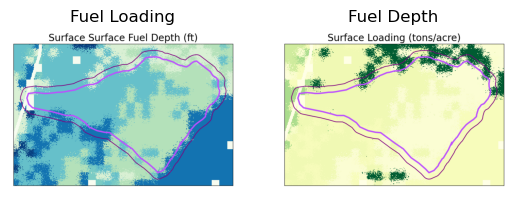

In [43]:
response_a = requests.get(lf_fueldepth[0])
response_b = requests.get(lf_fuelloading[0])

image_a = Image.open(BytesIO(response_a.content))
image_b = Image.open(BytesIO(response_b.content))

img_A = np.array(image_a)
img_B = np.array(image_b)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_A)
ax[0].set_title('Fuel Loading')
ax[0].axis('off')
ax[1].imshow(img_B)
ax[1].set_title('Fuel Depth')
ax[1].axis('off')


#### Canopy Fuels
##### Canopy Height Model

In [44]:
# check the canopy height model through bp3d

c = bp3d.Client(user=user, password=password)

plan = c.plan(f'{site_name} treemap-fbfm40')
ens = plan.ensemble(f'{site_name} treemap-fbfm40')
runs = ens.runs_df

fuel = ens.fuels[0]
treemap_chm = fuel.viz('png', 'chm', #"'all', 'bulk_density', 'fbfm', 'fuel_depth', 'loading', 'moisture', 'sav' or 'elevation',  'chm', 'dbh' or 'horizontal_trees_bulk_density'
   depth=0,
   use_cache=False,
   show={
       'legend': True,
   })
treemap_chm.sort()

c = bp3d.Client(user=user, password=password)

plan = c.plan(f'{site_name} treemap-meta-fbfm40')
ens = plan.ensemble(f'{site_name} treemap-meta-fbfm40')
runs = ens.runs_df

fuel = ens.fuels[0]
treemap_meta_chm = fuel.viz('png', 'chm', #"'all', 'bulk_density', 'fbfm', 'fuel_depth', 'loading', 'moisture', 'sav' or 'elevation',  'chm', 'dbh' or 'horizontal_trees_bulk_density'
   depth=0,
   use_cache=False,
   show={
       'legend': True,
   })
treemap_meta_chm.sort()

(np.float64(-0.5), np.float64(650.5), np.float64(458.5), np.float64(-0.5))

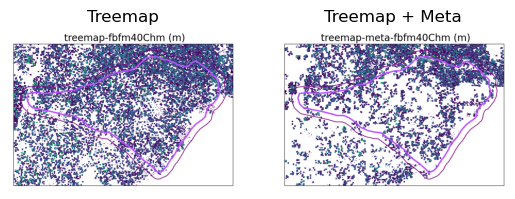

In [45]:
response_a = requests.get(treemap_chm[0])
response_b = requests.get(treemap_meta_chm[0])

image_a = Image.open(BytesIO(response_a.content))
image_b = Image.open(BytesIO(response_b.content))

img_A = np.array(image_a)
img_B = np.array(image_b)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_A)
ax[0].set_title('Treemap')
ax[0].axis('off')

ax[1].imshow(img_B)
ax[1].set_title('Treemap + Meta')
ax[1].axis('off')


### Vertical Profile Distribution

In [46]:
# check the canopy height model through bp3d

c = bp3d.Client(user=user, password=password)

plan = c.plan(f'{site_name} treemap-fbfm40')
ens = plan.ensemble(f'{site_name} treemap-fbfm40')
runs = ens.runs_df

fuel = ens.fuels[0]
treemap_dist = fuel.viz('png', 'vertical_trees_bulk_density')
treemap_dist.sort()

c = bp3d.Client(user=user, password=password)

plan = c.plan(f'{site_name} treemap-meta-fbfm40')
ens = plan.ensemble(f'{site_name} treemap-meta-fbfm40')
runs = ens.runs_df

fuel = ens.fuels[0]
treemap_meta_dist = fuel.viz('png', 'vertical_trees_bulk_density')
treemap_meta_dist.sort()

(np.float64(-0.5), np.float64(650.5), np.float64(490.5), np.float64(-0.5))

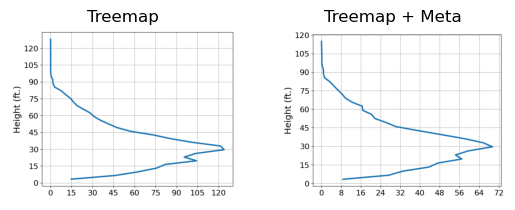

In [47]:
response_a = requests.get(treemap_dist[0])
response_b = requests.get(treemap_meta_dist[0])

image_a = Image.open(BytesIO(response_a.content))
image_b = Image.open(BytesIO(response_b.content))

img_A = np.array(image_a)
img_B = np.array(image_b)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_A)
ax[0].set_title('Treemap')
ax[0].axis('off')

ax[1].imshow(img_B)
ax[1].set_title('Treemap + Meta')
ax[1].axis('off')


### Compare Tree Inventories

#### Tree inventories

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [49]:
# read in the treelists from fastfuels
fftl_treemap = pd.read_csv('tree_inventory_1_export.csv')
fftl_meta = pd.read_csv('tree_inventory_2_export.csv')
# fftl_als = pd.read_csv('tree_inventory_3_export.csv')

fftl_treemap_gpd = gpd.GeoDataFrame(fftl_treemap, geometry = gpd.points_from_xy(fftl_treemap.X, fftl_treemap.Y), crs = 5070)
fftl_meta_gpd = gpd.GeoDataFrame(fftl_meta, geometry = gpd.points_from_xy(fftl_meta.X, fftl_meta.Y), crs = 5070)
# fftl_als_gpd = gpd.GeoDataFrame(fftl_als, geometry = gpd.points_from_xy(fftl_als.X, fftl_als.Y), crs = 3857)
# fftl_als_gpd = fftl_als_gpd.to_crs(5070)

# filter the trees in the burn unit
boundary = gpd.read_file('boundary.geojson')
boundary_5070 = boundary.to_crs(5070)

fftl_treemap_gpd = fftl_treemap_gpd.sjoin(boundary_5070)
fftl_meta_gpd = fftl_meta_gpd.sjoin(boundary_5070)
# fftl_als_gpd = fftl_als_gpd.sjoin(boundary_5070)


#### Species Distribution

In [51]:
treespeciescode = pd.read_csv('FIATreeSpeciesCode.csv')

fftl_treemap_gpd = fftl_treemap_gpd.merge(treespeciescode, on = 'SPCD')
fftl_meta_gpd = fftl_meta_gpd.merge(treespeciescode, on = 'SPCD')
# fftl_als_gpd = fftl_als_gpd.merge(treespeciescode, on = 'SPCD')


/var/folders/rp/zdr20wpx60j7227xn_x7mjqc0000gn/T/ipykernel_21194/3194920398.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Pastel2')


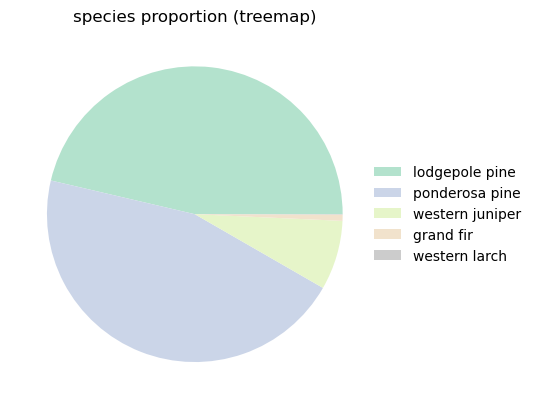

In [52]:
treemap_species = fftl_treemap_gpd.value_counts('COMMON_NAME', normalize = True).reset_index()

cmap = plt.cm.get_cmap('Pastel2')
colors = [cmap(i) for i in np.linspace(0, 1, treemap_species.shape[0])]

plt.pie(treemap_species.proportion, colors = colors)
plt.title(f'species proportion (treemap)')
plt.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), labels = treemap_species.COMMON_NAME, framealpha = 0)


In [53]:
treemap_species

,COMMON_NAME,proportion
0,lodgepole pine,0.463363
1,ponderosa pine,0.453549
2,western juniper,0.075891
3,grand fir,0.006706
4,western larch,0.000491


/var/folders/rp/zdr20wpx60j7227xn_x7mjqc0000gn/T/ipykernel_21194/1128438040.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Pastel2')


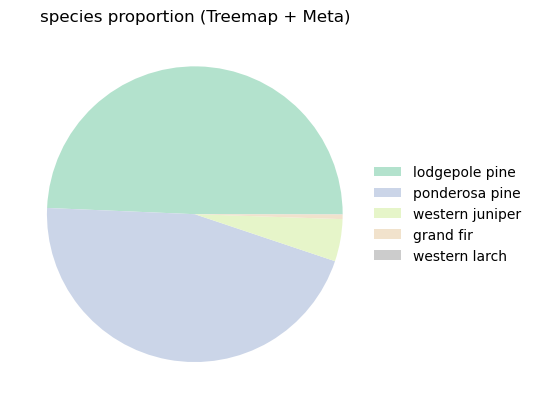

In [54]:
meta_species = fftl_meta_gpd.value_counts('COMMON_NAME', normalize = True).reset_index()

cmap = plt.cm.get_cmap('Pastel2')
colors = [cmap(i) for i in np.linspace(0, 1, meta_species.shape[0])]

plt.pie(meta_species.proportion, colors = colors)
plt.title(f'species proportion (Treemap + Meta)')
plt.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), labels = meta_species.COMMON_NAME, framealpha = 0)


In [55]:
meta_species

,COMMON_NAME,proportion
0,lodgepole pine,0.493283
1,ponderosa pine,0.455260
2,western juniper,0.046134
3,grand fir,0.005070
4,western larch,0.000253


In [56]:
# als_species = fftl_als_gpd.value_counts('COMMON_NAME', normalize = True).reset_index()

# cmap = plt.cm.get_cmap('Pastel2')
# colors = [cmap(i) for i in np.linspace(0, 1, als_species.shape[0])]

# plt.pie(als_species.proportion, colors = colors)
# plt.title(f'species proportion (ALS)')
# plt.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), labels = als_species.COMMON_NAME, framealpha = 0)


In [57]:
# als_species

#### Histograms

In [58]:
def plot_hist(fftl, maintitle):
    
    data1 = fftl.DIA.values / 2.54
    data2 = fftl.HT.values * 3.281
    data3 = fftl.CR.values * 100
    data4 = (1 - fftl.CR.values) * fftl.HT.values * 3.281
    
    all_data = [data1, data2, data3, data4]
    
    titles = ['Diameter (in)', 'Height (ft)', 'Crown Ratio (%)', 'Crown Base Height (ft)']
    xlab_list = ['Diameter (in)', 'Height (ft)', 'Crown Ratio (%)', 'Crown Base Height (ft)']
    
    
    # 2. Create figure and subplots (2 rows, 2 columns)
    fig, axs = plt.subplots(2, 2, 
                            tight_layout=True, 
                            # figsize=(10, 8)
                           )
    # fig, axs = plt.subplots(2, 2)
    # 3. Flatten the axes array for easy iteration
    axs = axs.ravel()
    
    # 4. Loop through data and plot on respective subplots
    for i, ax in enumerate(axs):
        ax.hist(all_data[i], bins=20) # Call hist on the Axes object
        ax.set_title(titles[i])
        ax.set_xlabel(xlab_list[i])
        ax.set_ylabel('Frequency')
    
    fig.suptitle(maintitle)
    # 5. Display the plots
    plt.show()


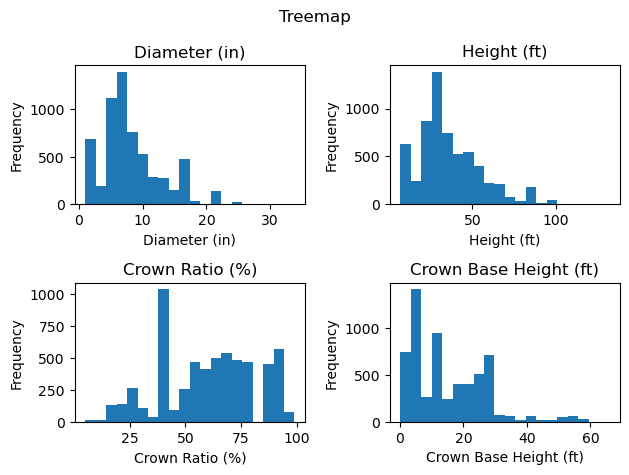

In [59]:
plot_hist(fftl_treemap_gpd, 'Treemap')

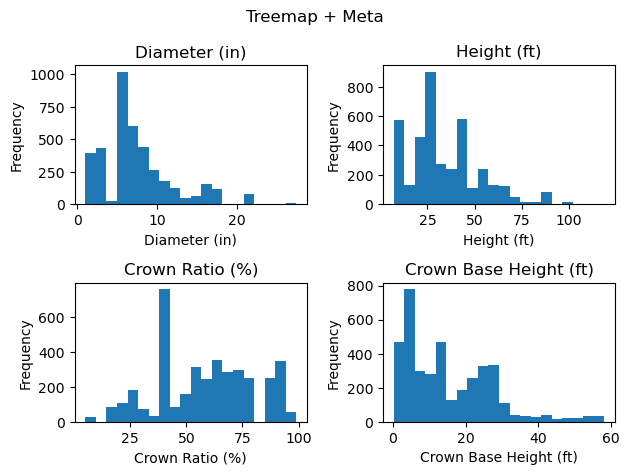

In [60]:
plot_hist(fftl_meta_gpd, 'Treemap + Meta')

In [61]:
# plot_hist(fftl_als_gpd, 'ALS')

#### Bubble plots

In [63]:
# summarize treelist to create bubble plots

def summarize_treelist(fftl):

    #add diameter in inches
    
    fftl['DIA_in'] = fftl['DIA'] / 2.54

    conditions = [
        (fftl['DIA_in'] < 2),
        (fftl['DIA_in'] >= 2) & (fftl['DIA_in'] < 4),
        (fftl['DIA_in'] >= 4) & (fftl['DIA_in'] < 8),
        (fftl['DIA_in'] >= 8) & (fftl['DIA_in'] < 12),
        (fftl['DIA_in'] >= 12) & (fftl['DIA_in'] < 16),
        (fftl['DIA_in'] >= 16) & (fftl['DIA_in'] < 20),
        (fftl['DIA_in'] >= 20)
    ]
    choices = ['0-2', '2-4', '4-8', '8-12', '12-16', '16-20', '20+']
    
    fftl['diam_group'] = np.select(conditions, choices, default='NA')
    fftl['CBH'] = (1 - fftl.CR) * fftl.HT 

    #summarize treelist
    fftl_subset = fftl.groupby(['diam_group'])[['HT', 'CR', 'CBH']].mean().reset_index()

    #add the trees per acre
    domain_size = boundary_5070.area[0]/4047
    
    fftl_subset['TPA'] = fftl.groupby(['diam_group'])['TREE_ID'].count().reset_index()['TREE_ID']/domain_size
    fftl_subset = fftl_subset.set_index('diam_group').reindex(choices).reset_index()
    fftl_subset = fftl_subset.fillna(0)

    return(fftl_subset)

fftl_treemap_subset = summarize_treelist(fftl_treemap_gpd)
fftl_meta_subset = summarize_treelist(fftl_meta_gpd)

# fftl_als_gpd['TREE_ID'] = np.arange(fftl_als_gpd.shape[0])
# fftl_als_subset = summarize_treelist(fftl_als_gpd)


In [65]:

def bubble_plot(x, y, df, xlabel, ylabel, method):
    choices = ['0-2', '2-4', '4-8', '8-12', '12-16', '16-20', '20+']

    fig, ax = plt.subplots()
    
    scatter = ax.scatter(x, y, 
                edgecolor = 'darkgray',
                s = df.TPA, 
                c =df.index, 
                cmap = 'YlGn')
    handles_c, labels_c = scatter.legend_elements()
    
    # legend for diameter (color)
    legend1 = ax.legend(
        handles_c, 
        choices, 
        loc="upper left", 
        title="Diameter",
        bbox_to_anchor=(1, 0.7)
    )
    ax.add_artist(legend1) # Add the first legend back to the plot
    
    # legend for trees per acre (size)
    handles_s, labels_s = scatter.legend_elements(prop="sizes", alpha=0.6, num=3)
    legend2 = ax.legend(
        handles_s, 
        labels_s, 
        # loc=" left", 
        bbox_to_anchor=(1, 0.9),
        loc = 'center left',
        title="Trees per Acre"
    )
    
    
    # 
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Mean {xlabel} vs Mean {ylabel} - {method}")
    # ax.grid(True)
    
    # plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust the plot area (rect=[left, bottom, right, top])
    plt.show()

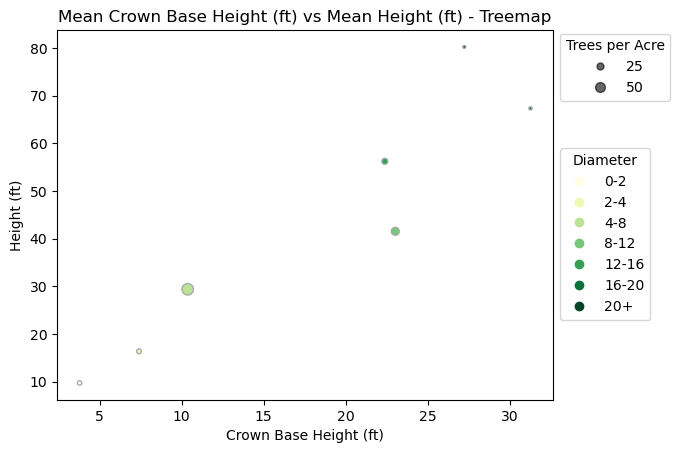

In [66]:
x = fftl_treemap_subset.CBH * 3.281
y = fftl_treemap_subset.HT * 3.281
df = fftl_treemap_subset
xlabel = 'Crown Base Height (ft)'
ylabel = 'Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap')

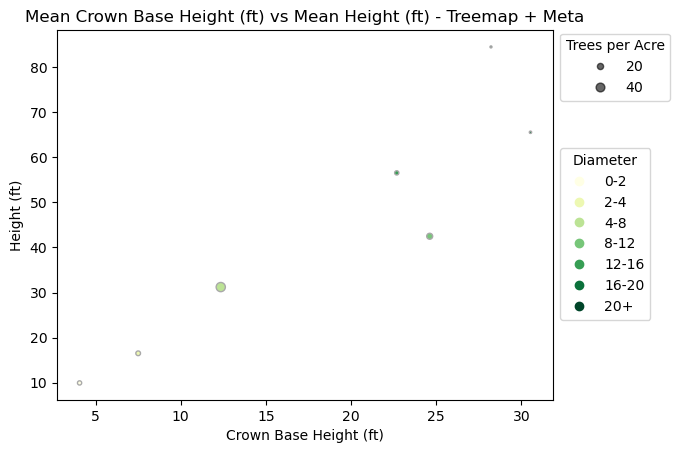

In [67]:
x = fftl_meta_subset.CBH * 3.281
y = fftl_meta_subset.HT * 3.281
df = fftl_meta_subset
xlabel = 'Crown Base Height (ft)'
ylabel = 'Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap + Meta')

In [68]:
# x = fftl_als_subset.CBH * 3.281
# y = fftl_als_subset.HT * 3.281
# df = fftl_als_subset
# xlabel = 'Crown Base Height (ft)'
# ylabel = 'Height (ft)'

# bubble_plot(x, y, df, xlabel, ylabel, 'ALS')

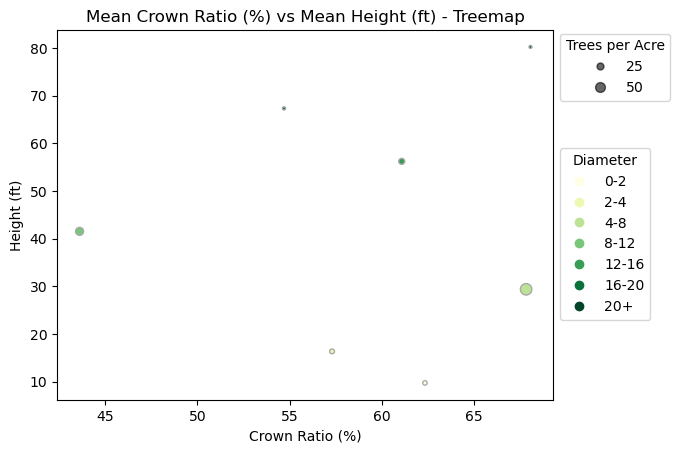

In [69]:
x = fftl_treemap_subset.CR * 100
y = fftl_treemap_subset.HT * 3.281
df = fftl_treemap_subset
xlabel = 'Crown Ratio (%)'
ylabel = 'Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap')

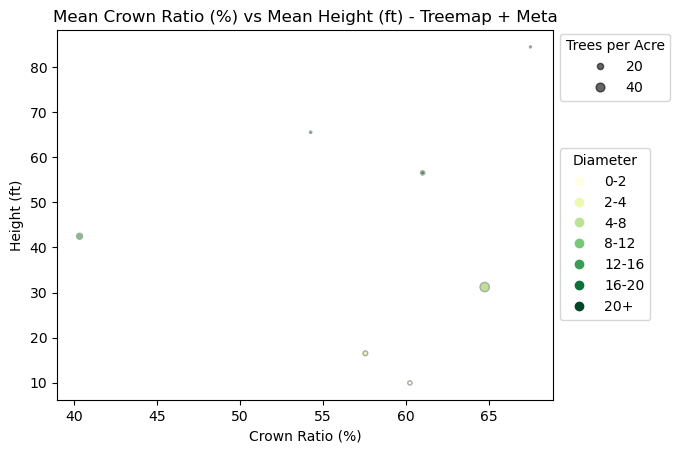

In [70]:
x = fftl_meta_subset.CR * 100
y = fftl_meta_subset.HT * 3.281
df = fftl_meta_subset
xlabel = 'Crown Ratio (%)'
ylabel = 'Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap + Meta')

In [71]:
# x = fftl_als_subset.CR * 100
# y = fftl_als_subset.HT * 3.281
# df = fftl_als_subset
# xlabel = 'Crown Ratio (%)'
# ylabel = 'Height (ft)'

# bubble_plot(x, y, df, xlabel, ylabel, 'ALS')

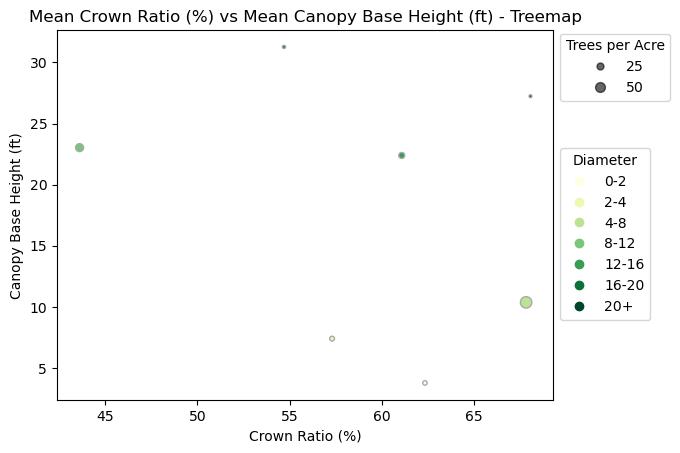

In [72]:
x = fftl_treemap_subset.CR * 100
y = fftl_treemap_subset.CBH * 3.281
df = fftl_treemap_subset
xlabel = 'Crown Ratio (%)'
ylabel = 'Canopy Base Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap')

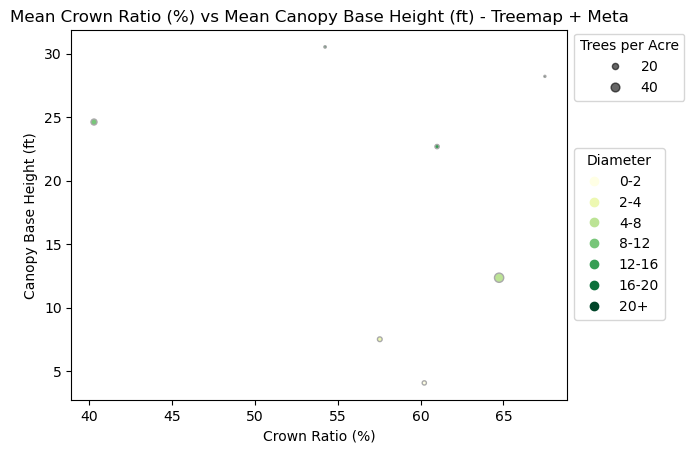

In [73]:
x = fftl_meta_subset.CR * 100
y = fftl_meta_subset.CBH * 3.281
df = fftl_meta_subset
xlabel = 'Crown Ratio (%)'
ylabel = 'Canopy Base Height (ft)'

bubble_plot(x, y, df, xlabel, ylabel, 'Treemap + Meta')

In [74]:
# x = fftl_als_subset.CR * 100
# y = fftl_als_subset.CBH * 3.281
# df = fftl_als_subset
# xlabel = 'Crown Ratio (%)'
# ylabel = 'Canopy Base Height (ft)'

# bubble_plot(x, y, df, xlabel, ylabel, 'ALS')

### Run the Model

Once you have reviewed the fuels layers, you can start the model on BP3D

In [84]:
workflow1.execute()
workflow2.execute()
# workflow3.execute()
# workflow4.execute()
# workflow5.execute()
# workflow6.execute()


### Access results from BP3D

#### Check BP3D account

Login to BurnPro3D to see the results when they are finished 


In [101]:
# from multiple ensembles, we can go through the runs of each ensemble and extract the outputs using BP3D SDK
ensemble_names = [f'{site_name} treemap-fbfm40',   f'{site_name} treemap-meta-fbfm40']

In [102]:
surface_consumption=[]
midstory_consumption=[]
canopy_consumption=[]
final_viz_url = []

# set up the BP3D Client
c = bp3d.Client(user=user, password=password)

for n, ensemble_name in enumerate(ensemble_names):
    plan = c.plan(ensemble_name)
    ens = plan.ensemble(ensemble_name)
    runs_df = ens.runs_df
    runs_df = runs_df.reset_index()

    viz = runs_df.viz[0]
    viz.sort()
    v = viz[0]
    url = v.split('_')
    t = [int(v.split('_')[4]) for v in viz]
    maxt = max(t)
    final_viz_url.append(f'{url[0]}_{url[1]}_{url[2]}_{url[3]}_{maxt}_{url[5]}')
    
    for i in np.arange(ens.runs_df.shape[0]):
        
        edf = runs_df.iloc[i]
    
        surface_consumption.append(edf.metrics['inside_surface_consumption'])
        midstory_consumption.append(np.sum(edf.metrics['consumption_t0_tNone_z1_z5']))
        canopy_consumption.append(np.sum(edf.metrics['consumption_t0_tNone_z6_zNone']))

In [103]:
pd.DataFrame({'Fuel Tile':ensemble_names,
 'Surface Consumption':surface_consumption,
 'Midstory Consumption': midstory_consumption,
 'Canopy Consumption': canopy_consumption
})

,Fuel Tile,Surface Consumption,Midstory Consumption,Canopy Consumption
0,sycan marsh treemap-fbfm40,0.504710,0.121328,0.020791
1,sycan marsh treemap-meta-fbfm40,0.503151,0.121413,0.016414


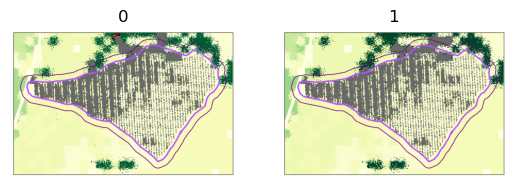

In [104]:
fig, ax = plt.subplots(1, len(ensemble_names))

for n, ensemble_name in enumerate(ensemble_names):
    response = requests.get(final_viz_url[n])
    image = Image.open(BytesIO(response.content))
    
    img = np.array(image)

    ax[n].imshow(img)
    ax[n].set_title(n)
    ax[n].axis('off')
